In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# Library visualisasi
import matplotlib.pyplot as plt 
import seaborn as sns 

In [27]:
data = pd.read_csv('D:/Developments/Penelitan Bu Rodhiyyah Mardhiyah/Data Bersih16Param.csv')

In [30]:
data.head()

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sub_Sektor             1171 non-null   object 
 1   No                     1171 non-null   int64  
 2   Nama_Perusahaan        1171 non-null   object 
 3   Tahun                  1171 non-null   int64  
 4   Current_Ratio          1171 non-null   float64
 5   Cash_Ratio             1171 non-null   float64
 6   DAR                    1171 non-null   float64
 7   DER                    1171 non-null   float64
 8   NPM                    1171 non-null   float64
 9   ROA                    1171 non-null   float64
 10  ROE                    1171 non-null   float64
 11  Kepemilikan_Mayoritas  1171 non-null   float64
 12  Komisaris_Independen   1171 non-null   int64  
 13  Insider_Ownership      1171 non-null   float64
 14  BoC_Size               1171 non-null   int64  
 15  BoC_

In [15]:
data['TMT_Size'] = data['TMT_Size_DK'] + data['TMT_Size_DD']

In [18]:
print(data[['TMT_Size','TMT_Size_DK','TMT_Size_DD']].head())

  TMT_Size TMT_Size_DK TMT_Size_DD
0    4  5           4           5 
1    4  5           4           5 
2    4  5           4           5 
3    4  5           4           5 
4    4  4           4           4 


In [32]:
#--- MENGGABUNGKAN TMT_ED_DK dan TMT_ED_DD MENJADI TMT_ED_SIZE
data['TMT_Size'] = data['TMT_Size_DK'] + data['TMT_Size_DD']

#--- MENGGABUNGKAN TMT_ED_DK dan TMT_ED_DD MENJADI TMT_ED_SIZE
data['TMT_Education'] = data['TMT_Education_DK'] + data['TMT_Education_DD']


In [33]:
# Ambil kolom yang diinginkan
selected = data[
    [
        "Current_Ratio", "Cash_Ratio", "DAR", "DER", "NPM", "ROA", "ROE",
        "Kepemilikan_Mayoritas", "Komisaris_Independen", "Insider_Ownership",
        "BoC_Size", "BoC_Education","Total_Asset", "Pertumbuhan_Revenue",'TMT_Size','TMT_Education',
        "Z_Score","Label"
    ]
]

In [34]:
# Rename kolom yang perlu diterjemahkan
selected = selected.rename(columns={
    "Kepemilikan_Mayoritas": "Majority_Ownership",
    "Komisaris_Independen": "Independent_Commissioner",
    "Total_Asset": "Total_Assets",
    "Pertumbuhan_Revenue": "Revenue_Growth"
})

# Tampilkan hasil
selected.head()

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Majority_Ownership,Independent_Commissioner,Insider_Ownership,BoC_Size,BoC_Education,Total_Assets,Revenue_Growth,TMT_Size,TMT_Education,Z_Score,Label
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,31860954000000,-0.2480,9,0,1.0310,Potensi Bangkrut
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,35767906000000,0.4761,9,0,0.9293,Potensi Bangkrut
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,44937292000000,0.1703,9,0,0.6619,Potensi Bangkrut
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,46562563000000,-0.1763,9,0,0.9795,Potensi Bangkrut
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,50043024000000,0.2158,8,0,0.7210,Potensi Bangkrut


In [36]:
# --- Final: Ambil 16 variabel + 1 label ---
data = selected[
    [
        'Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
        'Majority_Ownership', 'Independent_Commissioner', 'Insider_Ownership',
        'BoC_Size', 'BoC_Education', 'TMT_Size', 'TMT_Education',
        'Total_Assets', 'Revenue_Growth',
        'Z_Score','Label'
    ]
]

# Tampilkan beberapa baris pertama untuk memastikan
# 1. Hitung Statistik Deskriptif dan Transpose
statistik_deskriptif_vertikal = data.describe().T

# 2. Tentukan Nama File
NAMA_FILE = 'statistik_per_variabel.xlsx'

# 3. Simpan DataFrame Hasil Statistik ke File Excel
# (Pastikan Anda sudah menginstal openpyxl jika muncul error)
try:
    statistik_deskriptif_vertikal.to_excel(NAMA_FILE)
    print(f"File '{NAMA_FILE}' berhasil dibuat.")

    # 4. Unduh File ke Komputer Lokal Anda
    print("Proses unduhan dimulai.")

except Exception as e:
    print(f"Terjadi error saat menyimpan atau mengunduh: {e}")

File 'statistik_per_variabel.xlsx' berhasil dibuat.
Proses unduhan dimulai.


In [39]:
# Cek Missing Value pada tiap kolom/variabel
print('Mengecek Missing Value pada tiap kolomnya: ')
print(data.isna().sum())

Mengecek Missing Value pada tiap kolomnya: 
Current_Ratio               0
Cash_Ratio                  0
DAR                         0
DER                         0
NPM                         0
ROA                         0
ROE                         0
Majority_Ownership          0
Independent_Commissioner    0
Insider_Ownership           0
BoC_Size                    0
BoC_Education               0
TMT_Size                    0
TMT_Education               0
Total_Assets                0
Revenue_Growth              0
Z_Score                     0
Label                       0
dtype: int64


In [40]:
data = data.drop(columns='Label')

In [41]:
data.describe()

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Majority_Ownership,Independent_Commissioner,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size,TMT_Education,Total_Assets,Revenue_Growth,Z_Score
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1.171000e+03,1171.000000,1171.000000
mean,3.723117,1.122553,0.610017,0.995115,0.035773,0.024159,-0.365679,0.741887,1.822374,0.026482,3.450043,3.354398,6.993168,6.211785,5.883031e+12,2.054406,2.983543
std,11.680666,9.615405,0.219726,125.916301,0.396312,0.310248,11.395100,0.276776,0.838728,0.112062,1.367457,5.349649,2.566041,9.507958,1.125741e+13,27.765929,6.833481
min,0.040000,0.000000,0.000000,-3976.610000,-8.150000,-0.340000,-374.190000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.376020e+10,-2.869100,-9.627000
25%,1.005000,0.090000,0.495000,1.060000,0.000000,0.000000,0.000000,0.590000,2.000000,0.000000,3.000000,0.000000,6.000000,0.000000,5.110805e+11,-0.024450,0.764400
50%,2.190000,0.230000,0.660000,1.950000,0.060000,0.020000,0.060000,0.800000,2.000000,0.000000,4.000000,0.000000,7.000000,0.000000,1.616151e+12,0.057000,2.480600
75%,3.700000,0.525000,0.760000,3.210000,0.150000,0.040000,0.130000,0.990000,2.000000,0.000000,4.000000,7.000000,8.000000,14.000000,4.940984e+12,0.232400,3.950250
max,335.190000,289.770000,1.500000,1641.970000,1.760000,10.390000,4.320000,1.000000,5.000000,1.000000,8.000000,28.000000,15.000000,43.000000,7.175770e+13,545.364800,154.744600


array([[<Axes: title={'center': 'Current_Ratio'}>,
        <Axes: title={'center': 'Cash_Ratio'}>,
        <Axes: title={'center': 'DAR'}>, <Axes: title={'center': 'DER'}>],
       [<Axes: title={'center': 'NPM'}>, <Axes: title={'center': 'ROA'}>,
        <Axes: title={'center': 'ROE'}>,
        <Axes: title={'center': 'Majority_Ownership'}>],
       [<Axes: title={'center': 'Independent_Commissioner'}>,
        <Axes: title={'center': 'Insider_Ownership'}>,
        <Axes: title={'center': 'BoC_Size'}>,
        <Axes: title={'center': 'BoC_Education'}>],
       [<Axes: title={'center': 'TMT_Size'}>,
        <Axes: title={'center': 'TMT_Education'}>,
        <Axes: title={'center': 'Total_Assets'}>,
        <Axes: title={'center': 'Revenue_Growth'}>],
       [<Axes: title={'center': 'Z_Score'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

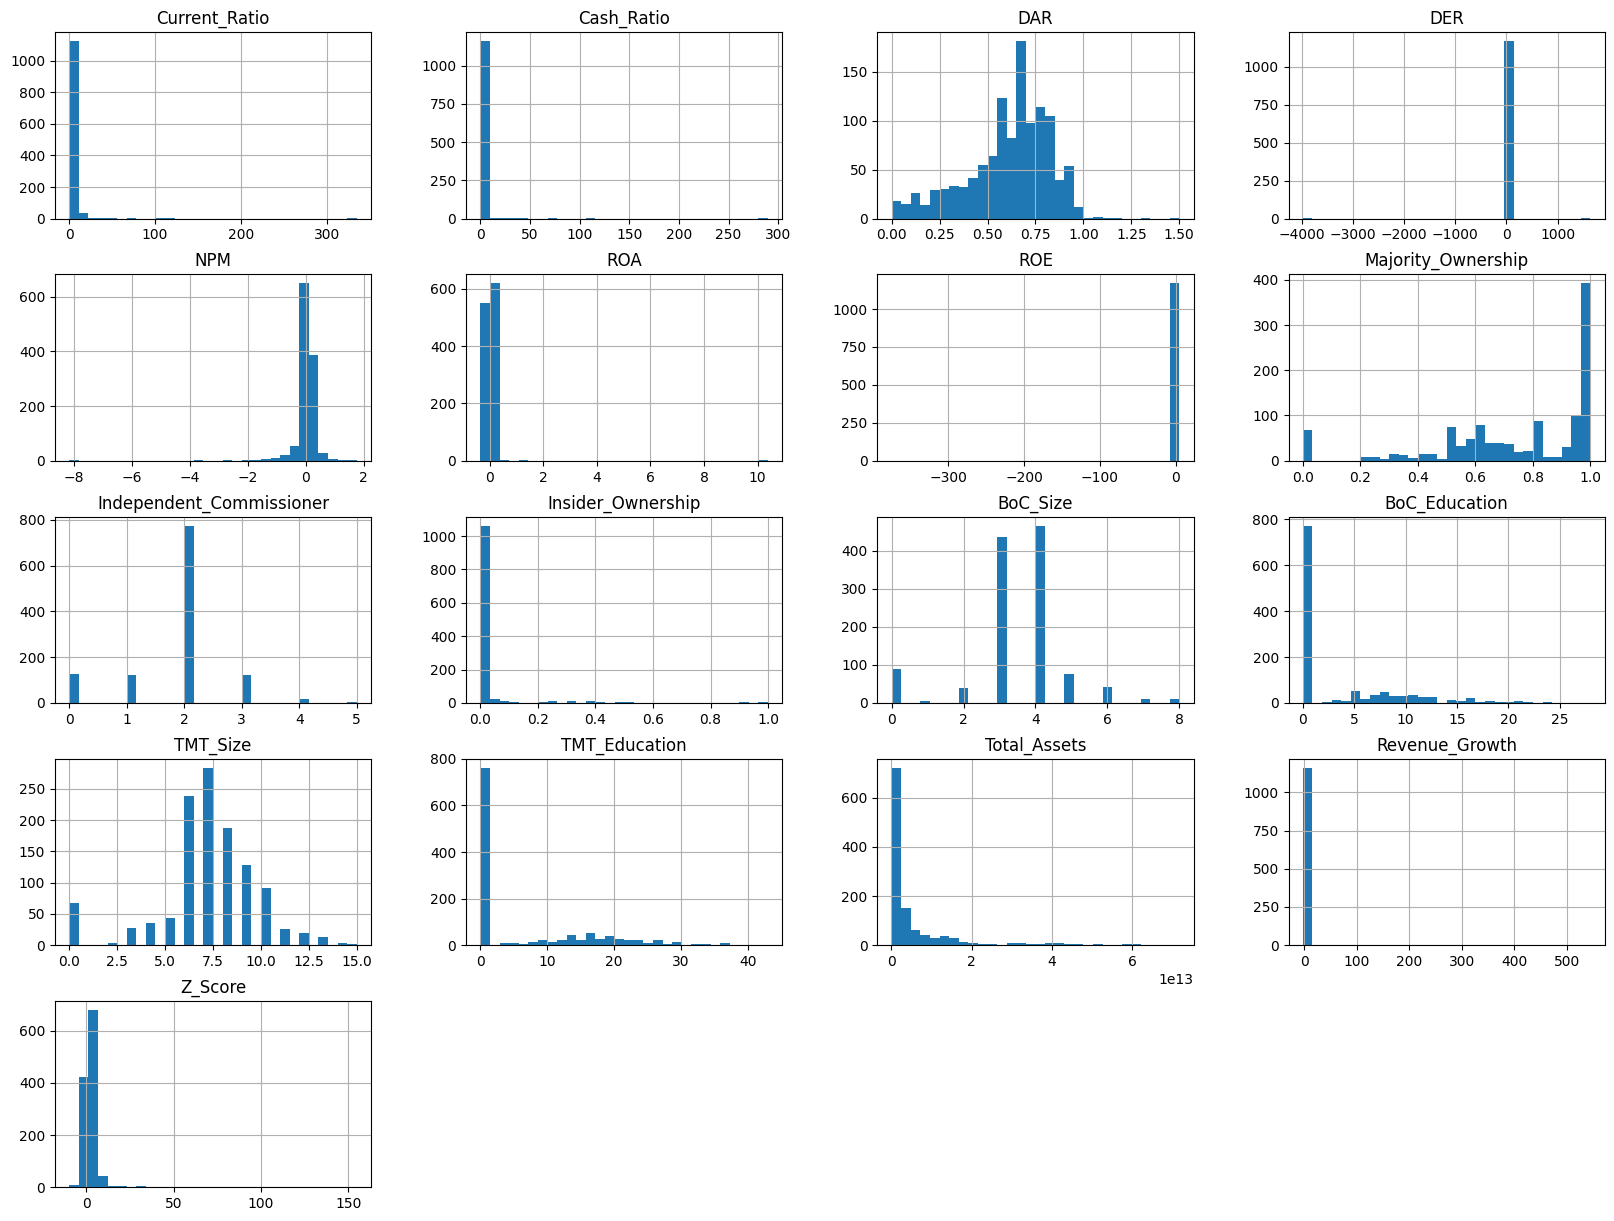

In [42]:
data.hist(bins=30, figsize=(20, 15))

maping_label: 
0 = Potential Bankruptcy
1 = Grey Zone
2 = Safe Zone

In [43]:
# Create a label column based on conditions
def label_zscore(z):
    if z < 1.1:
        return 0  # Potential Bankruptcy
    elif 1.1 <= z <= 2.6:
        return 1  # Grey Area
    else:
        return 2  # Safe Zone

# Terapkan fungsi ke kolom Z_Score
data['Category'] = data['Z_Score'].apply(label_zscore)

In [44]:
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Majority_Ownership,Independent_Commissioner,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size,TMT_Education,Total_Assets,Revenue_Growth,Z_Score,Category
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,9,0,31860954000000,-0.2480,1.0310,0
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,9,0,35767906000000,0.4761,0.9293,0
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,9,0,44937292000000,0.1703,0.6619,0
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,9,0,46562563000000,-0.1763,0.9795,0
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,8,0,50043024000000,0.2158,0.7210,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,7,0,15801971000000,-0.1372,6.6763,2
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,7,0,16149482000000,0.1508,6.5564,2
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,7,0,16468014000000,-0.0317,6.5906,2
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,7,0,16787071000000,0.0580,6.2599,2


In [45]:
# cek distribusi label
data['Category'].value_counts()

Category
2    567
0    391
1    213
Name: count, dtype: int64

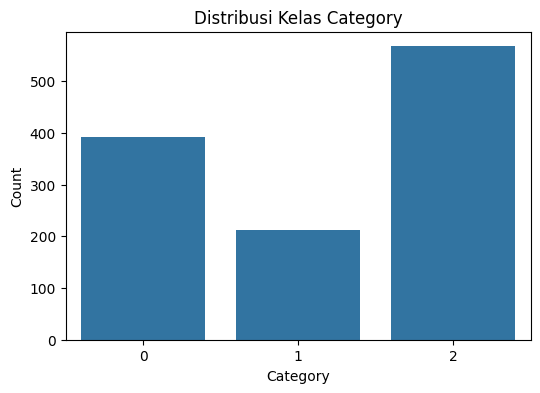

In [48]:
import matplotlib.pyplot as plt
from numpy import sort
import seaborn as sns

# Barplot untuk distribusi Category
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=data)
plt.title('Distribusi Kelas Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

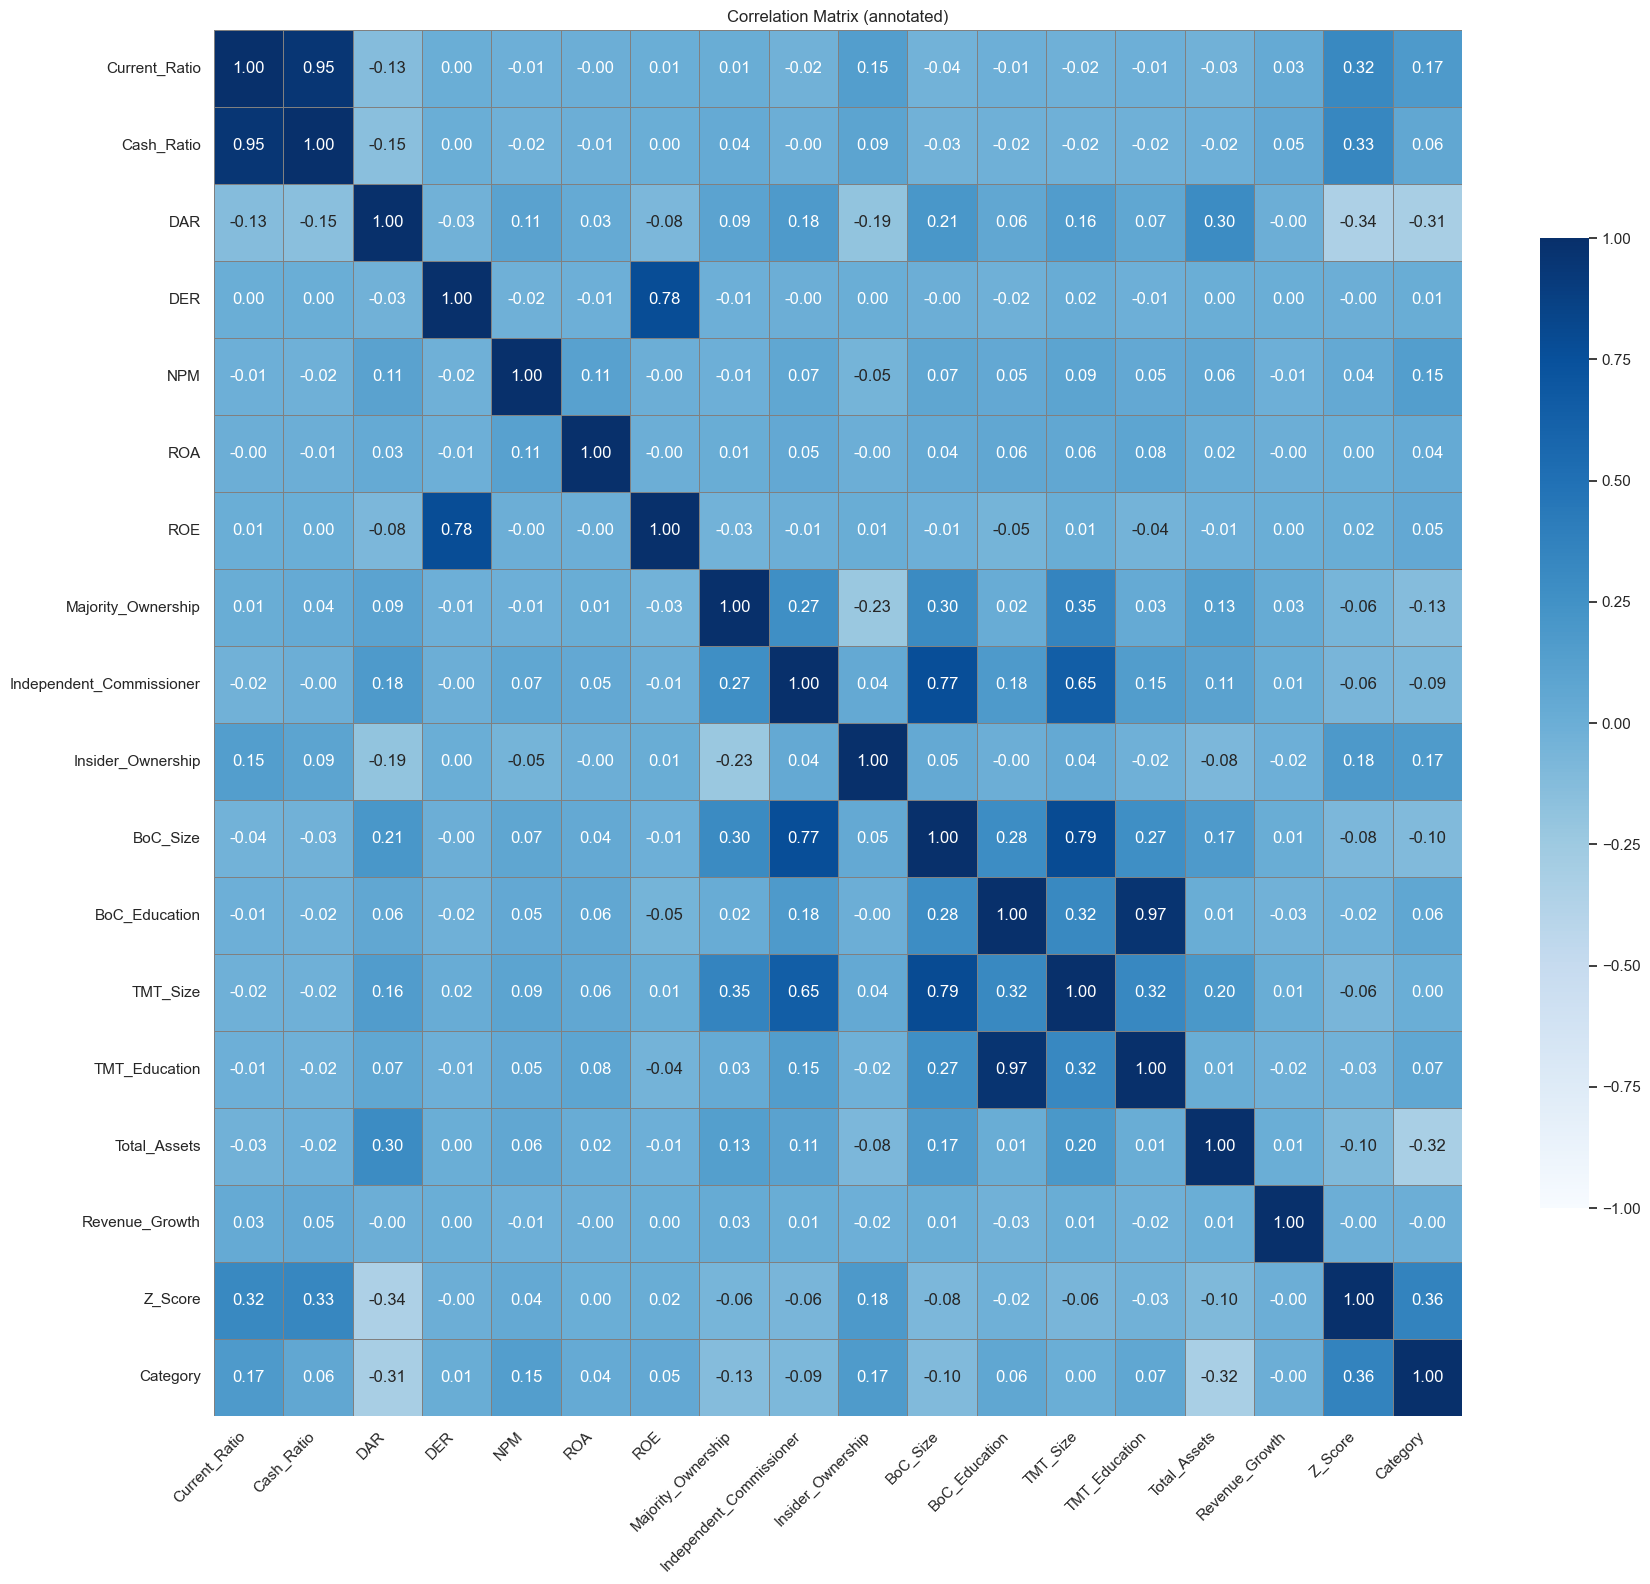

In [49]:
# Correlation heatmap dengan anotasi dan tema warna biru
plt.figure(figsize=(18, 16))
corr = data.select_dtypes(include=[np.number]).corr()  # hanya kolom numerik
sns.set(style='white')
mask = np.zeros_like(corr, dtype=bool)
# Tidak masking, tapi disiapkan jika ingin menyembunyikan diagonal/upper triangle
# mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix (annotated)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
data_clean = data.drop(columns=['Z_Score'])

In [51]:
data = data_clean.copy()

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Current_Ratio             1171 non-null   float64
 1   Cash_Ratio                1171 non-null   float64
 2   DAR                       1171 non-null   float64
 3   DER                       1171 non-null   float64
 4   NPM                       1171 non-null   float64
 5   ROA                       1171 non-null   float64
 6   ROE                       1171 non-null   float64
 7   Majority_Ownership        1171 non-null   float64
 8   Independent_Commissioner  1171 non-null   int64  
 9   Insider_Ownership         1171 non-null   float64
 10  BoC_Size                  1171 non-null   int64  
 11  BoC_Education             1171 non-null   int64  
 12  TMT_Size                  1171 non-null   int64  
 13  TMT_Education             1171 non-null   int64  
 14  Total_As

In [75]:
data.columns

Index(['Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
       'Majority_Ownership', 'Independent_Commissioner', 'Insider_Ownership',
       'BoC_Size', 'BoC_Education', 'TMT_Size', 'TMT_Education',
       'Total_Assets', 'Revenue_Growth', 'Category'],
      dtype='object')

In [53]:
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Majority_Ownership,Independent_Commissioner,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size,TMT_Education,Total_Assets,Revenue_Growth,Category
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,9,0,31860954000000,-0.2480,0
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,9,0,35767906000000,0.4761,0
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,9,0,44937292000000,0.1703,0
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,9,0,46562563000000,-0.1763,0
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,8,0,50043024000000,0.2158,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,7,0,15801971000000,-0.1372,2
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,7,0,16149482000000,0.1508,2
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,7,0,16468014000000,-0.0317,2
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,7,0,16787071000000,0.0580,2


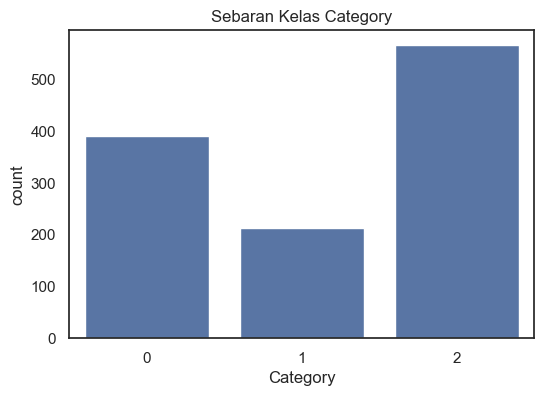

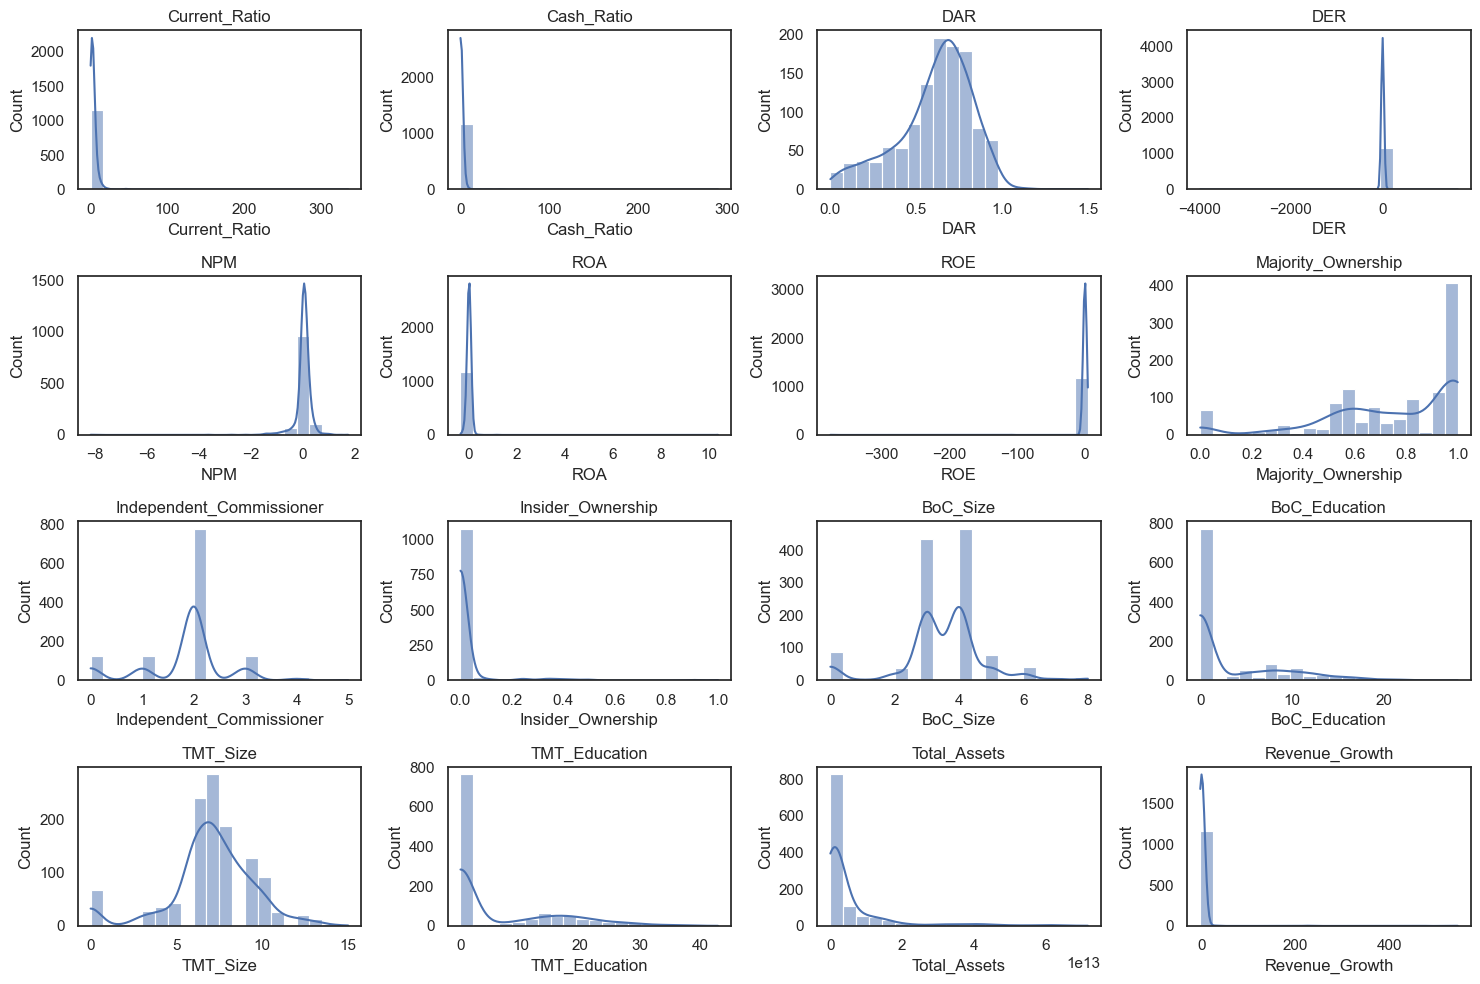

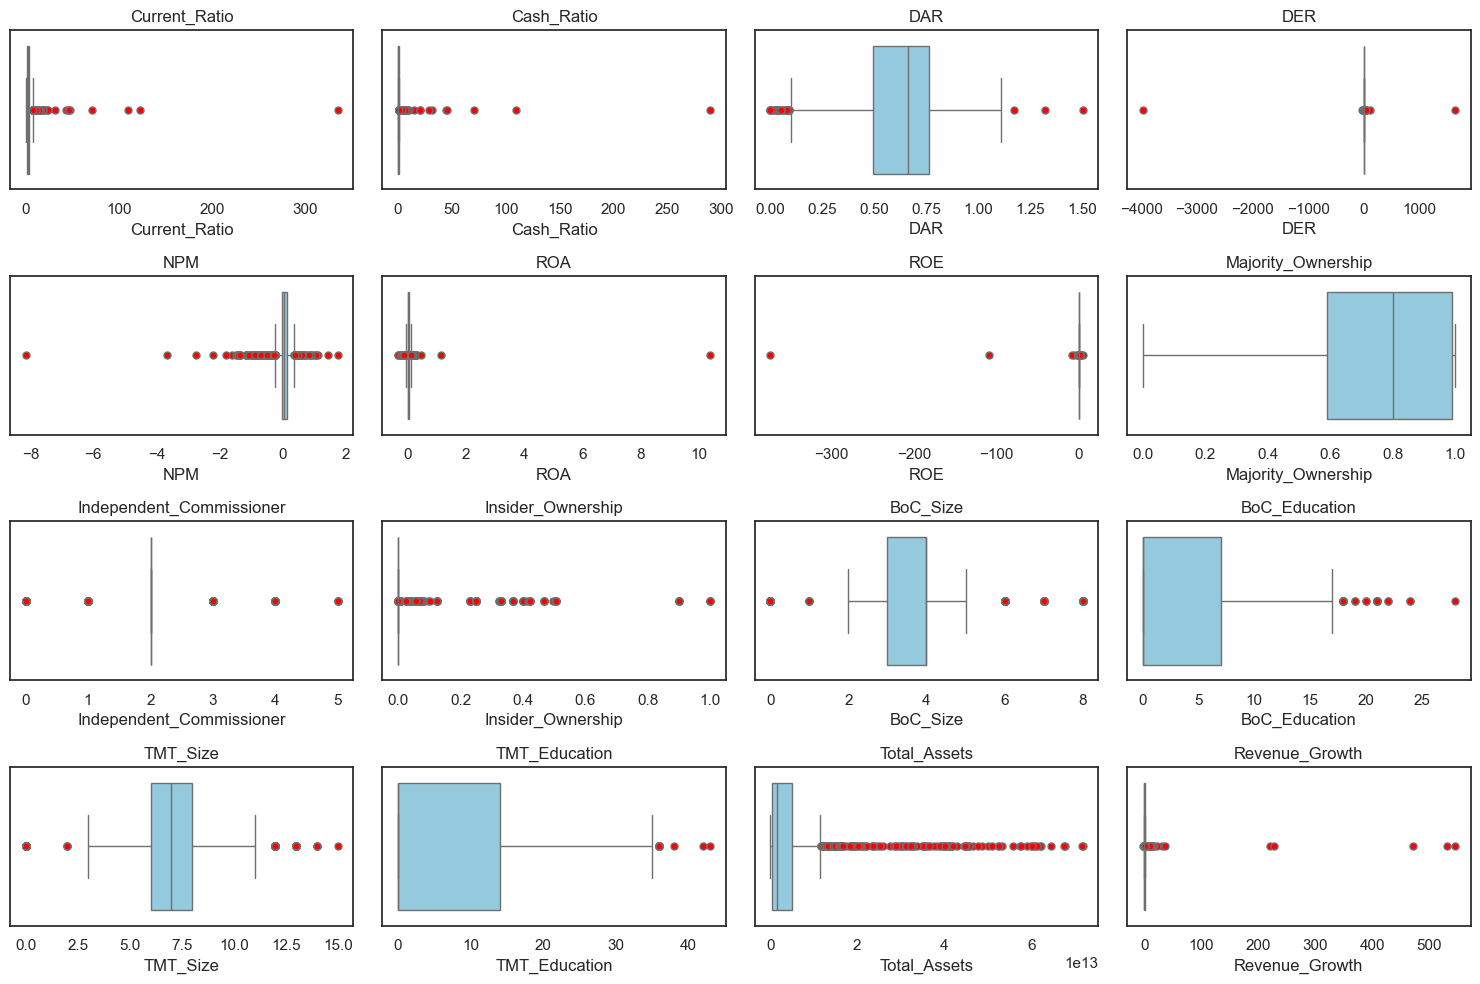

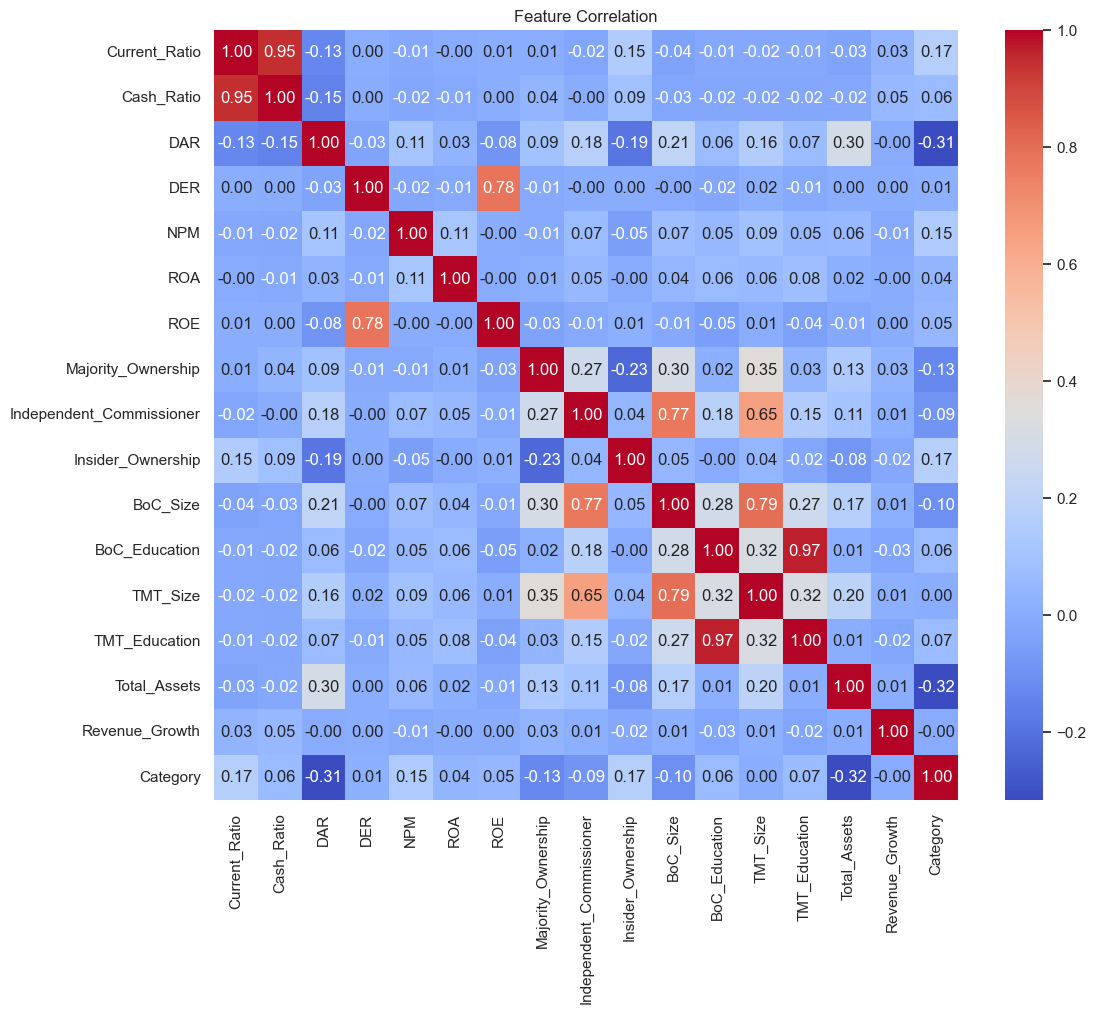

In [54]:
#-- MELIHAT SEBARAN DATA
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=data)
plt.title('Sebaran Kelas Category')
plt.show()

# 2️⃣ Distribusi numerik tiap fitur
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('Category')

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4,4,i)
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

#--Skewness → misal Revenue_Growth cenderung ke kanan/positif.
#--Sebaran → apakah normal, uniform, atau terpusat.


# Boxplot untuk cek outlier ekstrim
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(x=data[col], color='skyblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    plt.title(col)
plt.tight_layout()
plt.show()

# 3️⃣ Heatmap korelasi
plt.figure(figsize=(12,10))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Feature Correlation')
plt.show()

#-- Nilai mendekati ±1 → korelasi tinggi.
#-- Nilai mendekati 0 → korelasi lemah.


In [55]:
#-- CEK OUTLIER
numeric_cols = data.select_dtypes(include=['float64','int64']).columns.drop('Category')

outlier_info = {}

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)][col]
    outlier_info[col] = outliers
    print(f"{col}: {len(outliers)} outlier(s)")


Current_Ratio: 97 outlier(s)
Cash_Ratio: 133 outlier(s)
DAR: 36 outlier(s)
DER: 117 outlier(s)
NPM: 157 outlier(s)
ROA: 105 outlier(s)
ROE: 118 outlier(s)
Majority_Ownership: 0 outlier(s)
Independent_Commissioner: 396 outlier(s)
Insider_Ownership: 138 outlier(s)
BoC_Size: 154 outlier(s)
BoC_Education: 25 outlier(s)
TMT_Size: 108 outlier(s)
TMT_Education: 11 outlier(s)
Total_Assets: 170 outlier(s)
Revenue_Growth: 150 outlier(s)


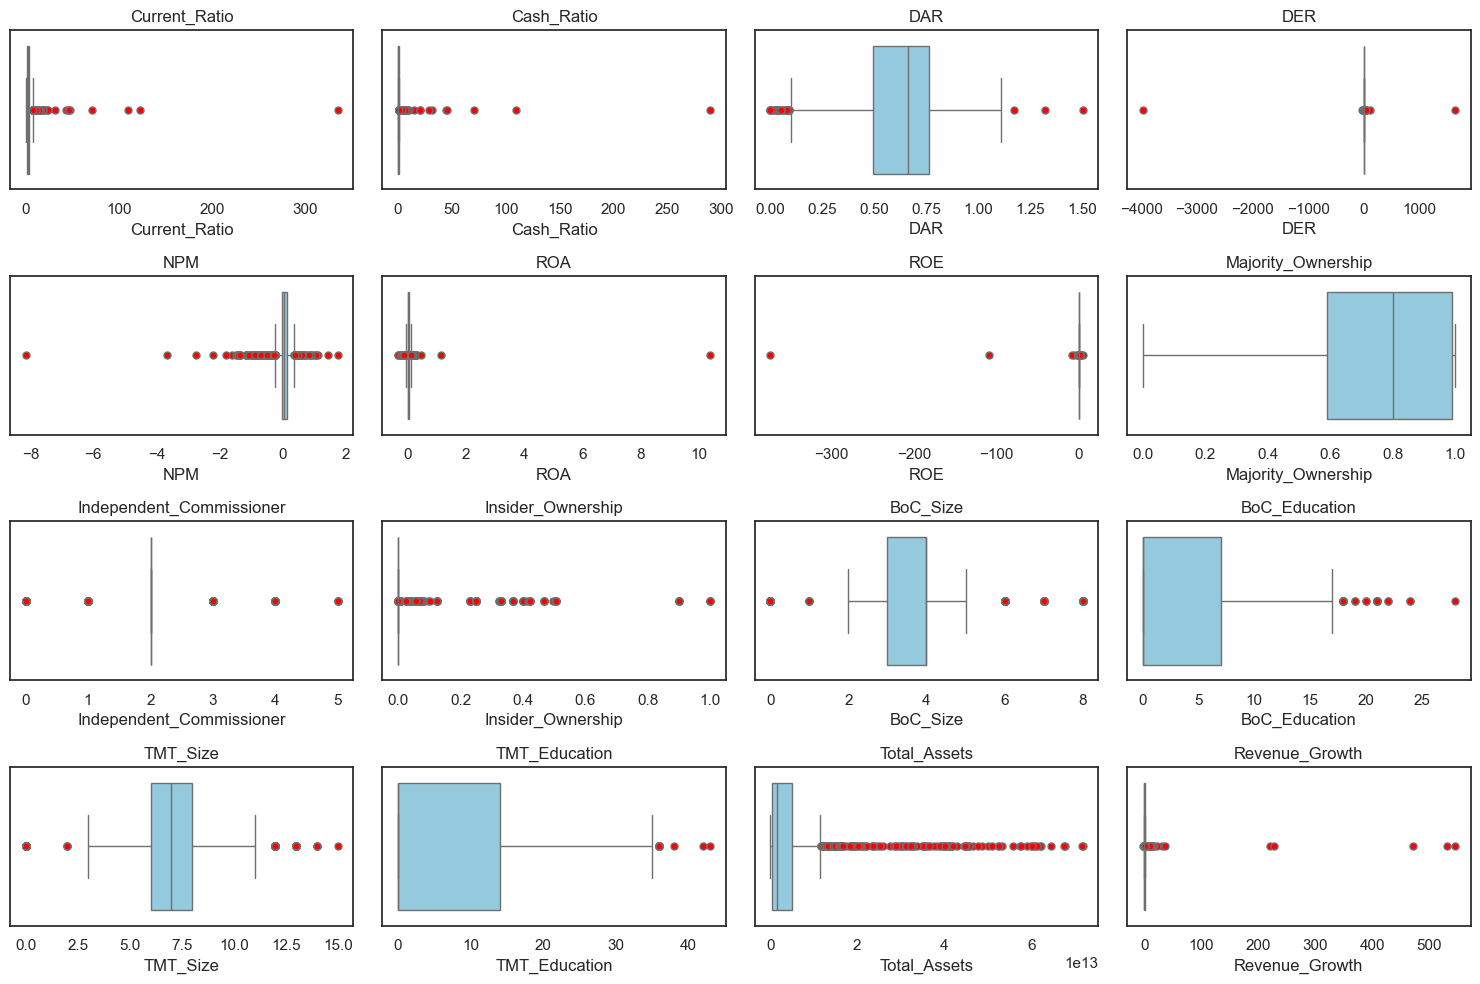

In [56]:
#visualisasi Deteksi outlier pada semua kolom numerik
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(x=data[col], color='skyblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    plt.title(col)
plt.tight_layout()
plt.show()


In [57]:
# ======================================================
# 1️⃣ Pisahkan fitur dan target
# ======================================================
X = data.drop(columns=['Category'])
y = data['Category']

In [58]:
from sklearn.preprocessing import StandardScaler

# ======================================================
# 2️⃣ Standardisasi fitur (opsional tapi direkomendasikan)
# ======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
# ======================================================
# 2️⃣ Standardisasi fitur (opsional tapi direkomendasikan)
# ======================================================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [60]:
# Tambahkan konstanta untuk intercept
X_scaled = sm.add_constant(X_scaled)  # masih DataFrame

In [61]:
# ======================================================
# 3️⃣ Split data (train-test)
# ======================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [62]:
# ======================================================
# 4️⃣ Buat model MNLogit
# ======================================================

import statsmodels.api as sm

mnlogit_model = sm.MNLogit(y_train, X_train)
mnlogit_result = mnlogit_model.fit(method='lbfgs')

print(mnlogit_result.summary())


                          MNLogit Regression Results                          
Dep. Variable:               Category   No. Observations:                  936
Model:                        MNLogit   Df Residuals:                      902
Method:                           MLE   Df Model:                           32
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                  0.3575
Time:                        16:37:12   Log-Likelihood:                -617.87
converged:                      False   LL-Null:                       -961.61
Covariance Type:            nonrobust   LLR p-value:                4.611e-124
              Category=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.4162      0.220      1.896      0.058      -0.014       0.846
Current_Ratio                5.3983      1.162      4.646      0.000       3.121       7.

d:\Developments\Penelitan Bu Rodhiyyah Mardhiyah\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



========= Multinomial Logit (MNLogit) Evaluation =================
Accuracy : 0.7617021276595745
Precision: 0.731975122458208
Recall   : 0.7617021276595745
F1-Score : 0.7206615133971342

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.88      0.80        78
           1       0.55      0.14      0.22        43
           2       0.81      0.91      0.86       114

    accuracy                           0.76       235
   macro avg       0.69      0.65      0.63       235
weighted avg       0.73      0.76      0.72       235



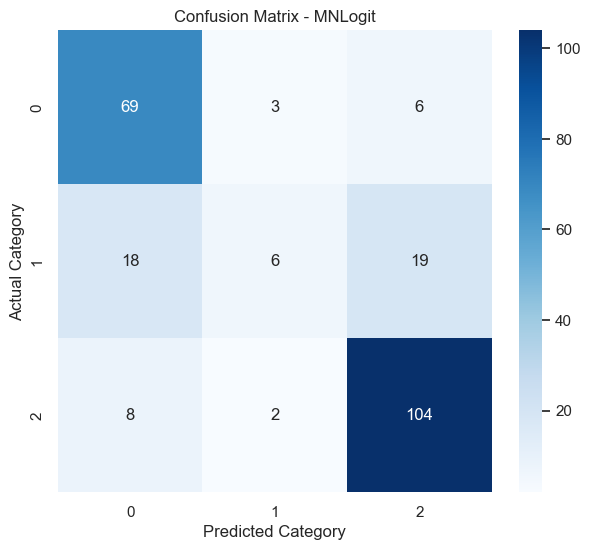

In [70]:
print("\n========= Multinomial Logit (MNLogit) Evaluation =================")
print("Accuracy :", accuracy_score(y_test,  y_pred_class))
print("Precision:", precision_score(y_test,  y_pred_class, average='weighted'))
print("Recall   :", recall_score(y_test,  y_pred_class, average='weighted'))
print("F1-Score :", f1_score(y_test,  y_pred_class, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test,  y_pred_class))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
labels = np.unique(y)  # kelas unik

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix - MNLogit')
plt.show()

In [66]:
import joblib

# Asumsikan 'model_mn_logit' adalah model yang sudah Anda latih
# dan 'scaler_data' adalah objek scaler yang sudah Anda fit
# pada data training

# 💾 Menyimpan Model
joblib.dump(mnlogit_result, 'model_mn_logit.pkl')

# 💾 Menyimpan Scaler
joblib.dump(scaler, 'scaler_data.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!


# **Prediksi**

In [72]:
import joblib

# Memuat Kembali Model
model = joblib.load('model_mn_logit.pkl')

# Memuat Kembali Scaler
scaler = joblib.load('scaler_data.pkl')

print("Model dan Scaler berhasil dimuat kembali!")

Model dan Scaler berhasil dimuat kembali!


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
pd.options.display.float_format = '{:,.4f}'.format

# Asumsi: model dan scaler sudah dimuat dengan joblib/pickle

# --- BAGIAN INPUT DATA TIDAK DIUBAH ---
print("Masukkan nilai untuk 16 variabel berikut:")

features = [
    'Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
    'Majority_Ownership', 'Independent_Commissioner', 'Insider_Ownership',
    'BoC_Size', 'BoC_Education', 'TMT_Size', 'TMT_Education',
    'Total_Assets', 'Revenue_Growth'
]

user_input = {}
for feature in features:
    value = float(input(f"Masukkan {feature}: "))
    user_input[feature] = value

# Buat DataFrame dari input
# PENTING: Pastikan urutan kolom sesuai dengan 'features'
input_df = pd.DataFrame([user_input], columns=features) # <--- Perubahan Kecil untuk Jaminan Urutan

# Pastikan input_scaled adalah (1, 16)
input_scaled = np.asarray(input_scaled).reshape(1, -1)

# Tambah konstanta secara MANUAL (PALING AMAN)
input_scaled_with_const = np.hstack(
    [np.ones((input_scaled.shape[0], 1)), input_scaled]
)

print("\nRingkasan Input Data:")
print(f"Jumlah Variabel : {input_df.shape[1]}")
print(f"Jumlah Observasi: {input_df.shape[0]}")
print("\nDetail Nilai Variabel:")
print(input_df.T.rename(columns={0: "Nilai"}))

# Prediksi probabilitas
pred_prob = model.predict(input_scaled_with_const)

# Ambil kelas dengan probabilitas tertinggi
pred_class = np.argmax(pred_prob, axis=1)[0]

label_map = {
    0: 'Potential Bankruptcy',
    1: 'Grey Zone',
    2: 'Safe Zone'
}

print(f"\nHasil Prediksi: {label_map[pred_class]}")
print(f"Probabilitas: {pred_prob[0]}")


Masukkan nilai untuk 16 variabel berikut:

Ringkasan Input Data:
Jumlah Variabel : 16
Jumlah Observasi: 1

Detail Nilai Variabel:
                                           Nilai
Current_Ratio                             0.5200
Cash_Ratio                                0.1800
DAR                                       0.7900
DER                                       3.8500
NPM                                       0.0900
ROA                                       0.0300
ROE                                       0.1300
Majority_Ownership                        0.8000
Independent_Commissioner                  2.0000
Insider_Ownership                         0.0000
BoC_Size                                  4.0000
BoC_Education                             0.0000
TMT_Size                                  9.0000
TMT_Education                             0.0000
Total_Assets             31,860,954,000,000.0000
Revenue_Growth                           -0.2480

Hasil Prediksi: Potential Bankruptcy